In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Exponential decay function

In [3]:
def exp_decay(t, a, lambda_val):
    return a * np.exp(-lambda_val * t)

In [4]:
df = pd.read_csv("sim_experiment_results.csv")
df.head()

,attempt_1,attempt_2,attempt_3,attempt_4,attempt_5,attempt_6,attempt_7,attempt_8,attempt_9,attempt_10
0,18.64,7.83,2.87,1.45,1.51,0.11,0.11,0.44,0.00,0.56
1,23.18,7.63,3.52,2.47,1.48,0.11,0.44,0.33,0.89,0.78
2,23.48,5.40,3.18,2.30,1.23,0.78,0.78,0.33,1.00,0.67
3,15.30,6.57,4.56,2.38,1.63,0.33,0.78,0.11,0.67,0.22
4,20.25,7.47,2.79,1.40,1.78,1.00,0.11,0.67,0.89,1.00


In [5]:
len(df), len(df.columns)

(100, 10)

In [6]:
x_data = []
y_data = []
# Curve fit can accept 1d arrays only
for i in range(len(df)):
    x_temp = np.array(range(0, len(df.columns)))
    y_temp = list(df.iloc[i].values)
    
    x_data.extend(x_temp)
    y_data.extend(y_temp)

In [7]:
mean_vals = list(df.mean())
init_guess_a = mean_vals[0]
init_guess_lambda = 0.5
init_guess = [init_guess_a, init_guess_lambda]

In [8]:
# Fit the data
p_opt, p_cov = curve_fit(exp_decay, x_data, y_data, p0=init_guess)

In [9]:
p_opt

array([20.59709712,  0.89170902])

In [12]:
p_cov

array([[0.01521975, 0.00052629],
       [0.00052629, 0.00012647]])

# Checking fit

In [13]:
# Calculate R² (coefficient of determination)
y_pred = exp_decay(np.array(x_data), *p_opt)
ss_tot = np.sum((np.array(y_data) - np.mean(y_data))**2)
ss_res = np.sum((np.array(y_data) - y_pred)**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"R² = {r_squared:.4f}")

# Optionally, calculate adjusted R²
n = len(y_data)  # number of observations
p = 2  # number of parameters in the model (a and lambda)
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
print(f"Adjusted R² = {adjusted_r_squared:.4f}")

R² = 0.9587
Adjusted R² = 0.9586


# Plotting

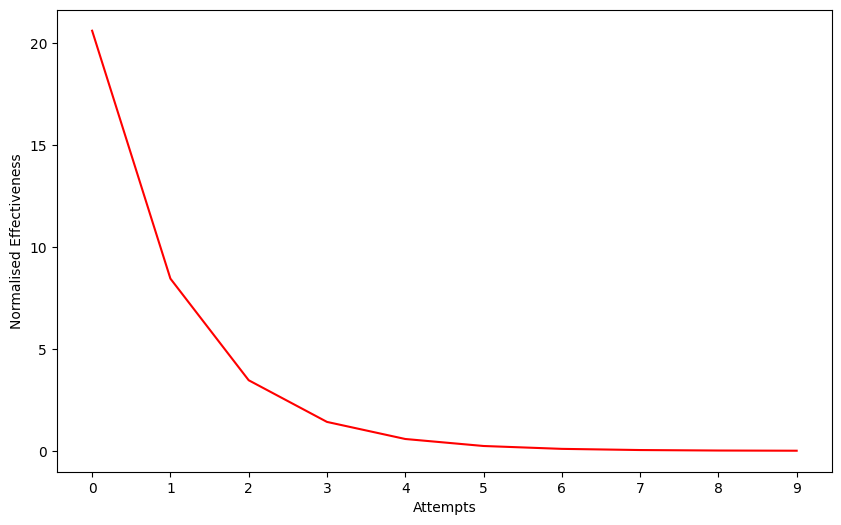

In [41]:
t_vals = np.array(range(0, len(df.columns)))
y_vals = exp_decay(t_vals, *p_opt)

plt.figure(figsize=(10, 6))
# plt.plot(x_data, y_data, 'o', label='Data')
plt.plot(t_vals, y_vals, 'r-', label='Fitted Curve')
plt.xticks(t_vals)

plt.xlabel("Attempts")
plt.ylabel("Normalised Effectiveness")
plt.show()

# Decay

In [ ]:
half_life = np.log(2) / p_opt[1]
half_life

0.7773243992194456

In [43]:
decay_percentages = [50, 75, 80, 90, 95, 99]
decay_times = []
decay_values = []
print("\nTime to reach specific decay percentages:")
for percent in decay_percentages:
    # Solving for t: t = -ln(1-p/100)/λ
    decay_factor = percent / 100
    time_to_decay = -np.log(1 - decay_factor) / p_opt[1]
    print(f"{percent}% decay: {time_to_decay:.2f} attempts")
    # Fig vals
    decay_times.append(time_to_decay)
    remain_value = p_opt[0] * (1 - decay_factor)
    decay_values.append(remain_value)



Time to reach specific decay percentages:
50% decay: 0.78 attempts
75% decay: 1.55 attempts
80% decay: 1.80 attempts
90% decay: 2.58 attempts
95% decay: 3.36 attempts
99% decay: 5.16 attempts


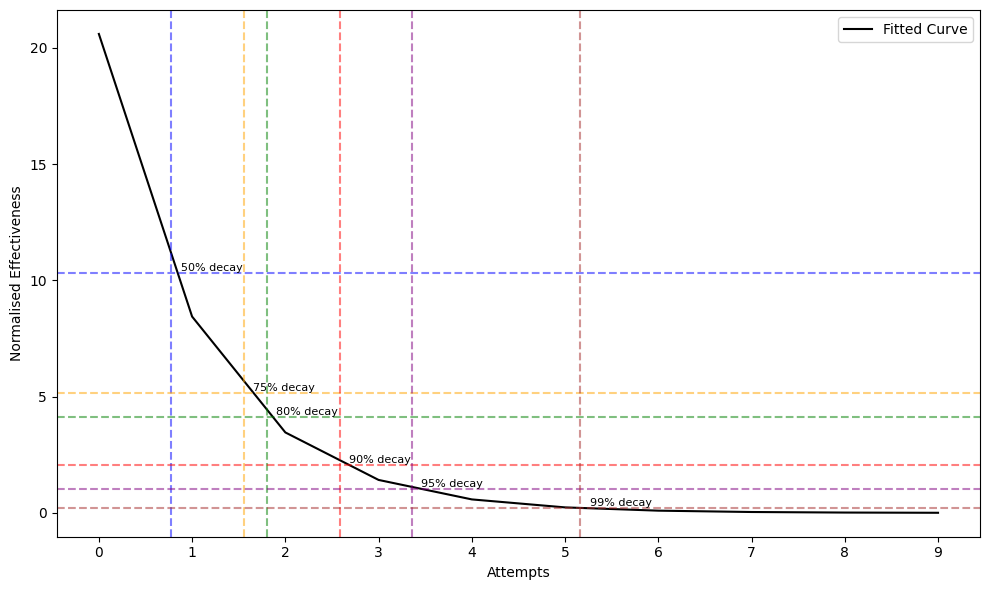

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_vals, y_vals, 'k-', label='Fitted Curve')
ax.set_xticks(t_vals)

colours = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for p, t, v, c in zip(decay_percentages, decay_times, decay_values, colours):
    # Lines
    ax.axhline(y=v, color=c, linestyle='--', alpha=0.5)
    ax.axvline(x=t, color=c, linestyle='--', alpha=0.5)
    
    # Text
    ax.text(t + 0.1, v, f"{p}% decay", 
            fontsize=8, verticalalignment='bottom')

# Add labels and legend
ax.set_xlabel("Attempts")
ax.set_ylabel("Normalised Effectiveness")
ax.legend()


plt.tight_layout()
plt.savefig("decay_percentages.png", dpi=300)
plt.show()

In [14]:
# Val from paper
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Exponential decay function
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

# Attempt indices
x = np.array([0, 1, 2, 3, 4, 5])

# Data from the table (ignoring error bars)
datasets = {
    "GPT-4-Preview-1106_1": [92.0, 3.8, 1.9, 1.1, 1.1, 0.2],
    "GPT-4-Preview-1106_2": [88.0, 8.2, 2.3, 0.8, 0.6, 0.0],
    "GPT-4-Preview-1106_3": [70.6, 18.0, 5.9, 3.0, 1.4, 1.2],
    "GPT-4-Preview-1106_4": [67.5, 17.2, 8.6, 3.2, 1.9, 1.6],

    "GPT-3.5-Turbo-1106_1": [81.9, 9.7, 4.0, 1.2, 2.1, 1.0],
    "GPT-3.5-Turbo-1106_2": [77.2, 13.2, 5.3, 1.9, 1.4, 1.0],
    "GPT-3.5-Turbo-1106_3": [74.6, 15.1, 5.2, 2.6, 1.3, 1.3],
    "GPT-3.5-Turbo-1106_4": [70.3, 16.2, 6.6, 3.3, 2.0, 1.5],

    "Qwen2.5-Coder-7B-Instruct_1": [79.3, 14.9, 2.6, 1.5, 0.6, 1.1],
    "Qwen2.5-Coder-7B-Instruct_2": [81.3, 13.1, 2.2, 1.7, 1.5, 0.2],
    "Qwen2.5-Coder-7B-Instruct_3": [60.9, 22.4, 7.5, 4.5, 2.9, 1.8],
    "Qwen2.5-Coder-7B-Instruct_4": [59.7, 21.6, 8.7, 5.0, 2.9, 2.2],
    "Qwen2.5-Coder-7B-Instruct_5": [67.2, 14.9, 7.1, 4.7, 3.4, 2.7],
}

# Fit data and compute R^2
results = {}
for key, y in datasets.items():
    popt, _ = curve_fit(exp_decay, x, y, maxfev=5000)
    y_pred = exp_decay(x, *popt)
    r2 = r2_score(y, y_pred)
    results[key] = {'params': popt, 'r2': r2}

results_sorted = dict(sorted(results.items(), key=lambda item: item[1]['r2'], reverse=True))
results_sorted


/tmp/ipykernel_222794/4090167750.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(exp_decay, x, y, maxfev=5000)
/tmp/ipykernel_222794/4090167750.py:9: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/tmp/ipykernel_222794/4090167750.py:9: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/tmp/ipykernel_222794/4090167750.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(exp_decay, x, y, maxfev=5000)
/tmp/ipykernel_222794/4090167750.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(exp_decay, x, y, maxfev=5000)
/tmp/ipykernel_222794/4090167750.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(exp_decay, x, y, maxfev=5000)
/tmp/ipykernel_222794/4090167750.py:9: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/tmp/ipykernel_222794/4

{'GPT-4-Preview-1106_3': {'params': array([70.45492032,  1.3154847 ]),
  'r2': 0.9982376144392238},
 'Qwen2.5-Coder-7B-Instruct_3': {'params': array([60.75933584,  0.98416888]),
  'r2': 0.9970997690751058},
 'GPT-4-Preview-1106_1': {'params': array([92.00000001, 60.79859722]),
  'r2': 0.9969902450775979},
 'Qwen2.5-Coder-7B-Instruct_4': {'params': array([59.36326029,  0.9561338 ]),
  'r2': 0.9960703241786245},
 'GPT-3.5-Turbo-1106_4': {'params': array([70.06804805,  1.3695925 ]),
  'r2': 0.9954160034198146},
 'GPT-4-Preview-1106_4': {'params': array([67.13348562,  1.23665436]),
  'r2': 0.9937057504756105},
 'GPT-4-Preview-1106_2': {'params': array([88.        , 51.20033082]),
  'r2': 0.9880520522992853},
 'Qwen2.5-Coder-7B-Instruct_5': {'params': array([66.84832332,  1.3547269 ]),
  'r2': 0.9867862315408336},
 'GPT-3.5-Turbo-1106_1': {'params': array([81.9       , 41.44857084]),
  'r2': 0.9773425443427565},
 'Qwen2.5-Coder-7B-Instruct_2': {'params': array([81.3       , 38.08971091]),
 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Exponential decay function with your preferred format
def exp_decay(t, a, lambda_val):
    return a * np.exp(-lambda_val * t)

# Attempt indices
x = np.array([0, 1, 2, 3, 4, 5])

# Data from the table (ignoring error bars)
datasets = {
    "GPT-4-Preview-1106_1": [92.0, 3.8, 1.9, 1.1, 1.1, 0.2],
    "GPT-4-Preview-1106_2": [88.0, 8.2, 2.3, 0.8, 0.6, 0.0],
    "GPT-4-Preview-1106_3": [70.6, 18.0, 5.9, 3.0, 1.4, 1.2],
    "GPT-4-Preview-1106_4": [67.5, 17.2, 8.6, 3.2, 1.9, 1.6],

    "GPT-3.5-Turbo-1106_1": [81.9, 9.7, 4.0, 1.2, 2.1, 1.0],
    "GPT-3.5-Turbo-1106_2": [77.2, 13.2, 5.3, 1.9, 1.4, 1.0],
    "GPT-3.5-Turbo-1106_3": [74.6, 15.1, 5.2, 2.6, 1.3, 1.3],
    "GPT-3.5-Turbo-1106_4": [70.3, 16.2, 6.6, 3.3, 2.0, 1.5],

    "Qwen2.5-Coder-7B-Instruct_1": [79.3, 14.9, 2.6, 1.5, 0.6, 1.1],
    "Qwen2.5-Coder-7B-Instruct_2": [81.3, 13.1, 2.2, 1.7, 1.5, 0.2],
    "Qwen2.5-Coder-7B-Instruct_3": [60.9, 22.4, 7.5, 4.5, 2.9, 1.8],
    "Qwen2.5-Coder-7B-Instruct_4": [59.7, 21.6, 8.7, 5.0, 2.9, 2.2],
    "Qwen2.5-Coder-7B-Instruct_5": [67.2, 14.9, 7.1, 4.7, 3.4, 2.7],
}

# Combine all data points for a global fit
x_all = np.array([])
y_all = np.array([])

for dataset in datasets.values():
    x_all = np.append(x_all, x)
    y_all = np.append(y_all, dataset)

# Fit the combined data
popt_all, _ = curve_fit(exp_decay, x_all, y_all, maxfev=5000)
y_pred_all = exp_decay(x_all, *popt_all)

# Calculate R² for all data
r2_all = r2_score(y_all, y_pred_all)

print(f"Global fit parameters: a = {popt_all[0]:.4f}, lambda = {popt_all[1]:.4f}")
print(f"Global R² = {r2_all:.4f}")

# # Also calculate R² for each dataset using the global parameters
# print("\nR² for individual datasets using global parameters:")
# for key, dataset in datasets.items():
#     y_pred = exp_decay(x, *popt_all)
#     r2 = r2_score(dataset, y_pred)
#     print(f"{key}: R² = {r2:.4f}")

# # Calculate the average of individual R² values
# individual_r2_values = [r2_score(dataset, exp_decay(x, *popt_all)) for dataset in datasets.values()]
# avg_r2 = np.mean(individual_r2_values)
# print(f"\nAverage R² across individual datasets: {avg_r2:.4f}")

# # Visualization of the global fit
# plt.figure(figsize=(12, 8))

# # Plot individual datasets
# for i, (key, dataset) in enumerate(datasets.items()):
#     plt.scatter(x, dataset, alpha=0.6, label=None)

# # Plot the global fit curve
# x_smooth = np.linspace(0, 5, 100)
# plt.plot(x_smooth, exp_decay(x_smooth, *popt_all), 'r-', linewidth=2, 
#          label=f'Global fit: a={popt_all[0]:.2f}, λ={popt_all[1]:.2f}, R²={r2_all:.4f}')

# plt.xlabel('Attempt Number')
# plt.ylabel('Success Rate (%)')
# plt.title('Exponential Decay Fit to All Datasets')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

Global fit parameters: a = 74.5206, lambda = 1.5618
Global R² = 0.9684


/tmp/ipykernel_222794/1479974038.py:8: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-lambda_val * t)
